# Выявление скрытой коммерческой активности

Цель здесь простая: найти среди consumer cards такие карты, которые по поведению похожи на business cards.

Я сначала делаю обычный supervised baseline, чтобы проверить что признаки вообще разделяют известные сегменты. Но финально не считаю consumer cards настоящими negative. Это важно, потому что по условию среди них как раз могут быть скрытые предприниматели. Поэтому после baseline идет PU-подход: business это positive, consumer это unlabeled фон.

**Важное ограничение по данным.** В описании кейса говорится про предпринимателей, которые могут получать платежи от многих контрагентов. Но в самих таблицах нет явного признака входящий это платеж или исходящий. Поэтому модель ниже ищет не “юридически доказанный бизнес”, а business-like поведение по видимым транзакциям: B2B MCC, SaaS/ads/cloud/logistics, recurring merchants, рабочие часы, foreign merchants, spend profile и концентрация по merchant/MCC.

То есть результат это не финальный verdict, а список leads для проверки банком

## 1. Setup

Сначала поднимаю базовое окружение и пути. Данные лежат в `data/raw`, MCC names в `data/clean`, а промежуточные card-level features и финальные outputs сохраняются в `data/processed`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from mdq.data import PROJECT_ROOT, load_data

pd.options.display.float_format = "{:,.4f}".format

RANDOM_STATE = 42
LOCAL_COUNTRY = "Kazakhstan"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

Зависимости для запуска: `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `fastparquet`, `jupyter`. Для моделей фиксирую random seed, чтобы результат можно было повторить

## 2. Data overview и quality checks

У нас есть две таблицы транзакций: известные business cards и consumer cards. Еще есть merchant reference. MCC names я добавил отдельно из справочника Mastercard, не для обучения как target, а чтобы нормально читать категории в EDA и explanations.

In [2]:
business, consumer, merchants, mcc = load_data()

data_overview = pd.DataFrame([
    {
        "table": "business_transactions",
        "rows": len(business),
        "cards": business["card_number"].nunique(),
        "min_timestamp": business["transaction_timestamp"].min(),
        "max_timestamp": business["transaction_timestamp"].max(),
    },
    {
        "table": "consumer_transactions",
        "rows": len(consumer),
        "cards": consumer["card_number"].nunique(),
        "min_timestamp": consumer["transaction_timestamp"].min(),
        "max_timestamp": consumer["transaction_timestamp"].max(),
    },
    {
        "table": "merchant_reference",
        "rows": len(merchants),
        "cards": np.nan,
        "min_timestamp": "",
        "max_timestamp": "",
    },
    {
        "table": "mcc_reference",
        "rows": len(mcc),
        "cards": np.nan,
        "min_timestamp": "",
        "max_timestamp": "",
    },
])

data_overview

,table,rows,cards,min_timestamp,max_timestamp
0,business_transactions,2997593,"25,000.0000",2025-10-01 00:00:00,2026-03-31 23:59:53
1,consumer_transactions,9832487,"80,000.0000",2025-10-01 00:00:00,2026-03-31 23:59:49
2,merchant_reference,2165,NaN,,
3,mcc_reference,1303,NaN,,


In [3]:
quality_checks = pd.DataFrame({
    "check": [
        "business duplicate rows",
        "consumer duplicate rows",
        "merchant duplicate rows",
        "business missing cells",
        "consumer missing cells",
        "merchant missing cells",
        "card overlap between business and consumer",
        "business non-positive amounts",
        "consumer non-positive amounts",
    ],
    "value": [
        business.duplicated().sum(),
        consumer.duplicated().sum(),
        merchants.duplicated().sum(),
        int(business.isna().sum().sum()),
        int(consumer.isna().sum().sum()),
        int(merchants.isna().sum().sum()),
        len(set(business["card_number"]).intersection(set(consumer["card_number"]))),
        int((business["transaction_amount_kzt"] <= 0).sum()),
        int((consumer["transaction_amount_kzt"] <= 0).sum()),
    ],
})
quality_checks

,check,value
0,business duplicate rows,0
1,consumer duplicate rows,0
2,merchant duplicate rows,0
3,business missing cells,0
4,consumer missing cells,0
5,merchant missing cells,0
6,card overlap between business and consumer,0
7,business non-positive amounts,0
8,consumer non-positive amounts,0


### Data issue: `MER_000000 + MCC 7012`

Есть один странный момент. В merchant reference `MER_000000` это Google Ads с MCC `7311`, но в транзакциях встречается тот же merchant id с MCC `7012`.

Если оставить как есть, часть строк будет ошибочно выглядеть как Google Ads. Поэтому raw поля не меняю, но для merchant-level анализа и фичей эта пара считается отдельным placeholder merchant key

In [4]:
def merchant_mcc_conflicts(transactions, segment):
    tx = transactions[["merchant_id", "mcc"]].copy()
    tx["mcc"] = tx["mcc"].astype(str)
    ref = merchants[["merchant_id", "mcc"]].copy()
    ref["mcc"] = ref["mcc"].astype(str)
    out = tx.merge(ref, on="merchant_id", how="left", suffixes=("_txn", "_ref"))
    conflict = out[out["mcc_txn"] != out["mcc_ref"]]
    return {
        "segment": segment,
        "conflict_rows": len(conflict),
        "conflict_share": len(conflict) / len(transactions),
        "top_conflict": conflict.groupby(["merchant_id", "mcc_txn", "mcc_ref"]).size().sort_values(ascending=False).head(1).to_dict(),
    }

pd.DataFrame([
    merchant_mcc_conflicts(business, "business"),
    merchant_mcc_conflicts(consumer, "consumer"),
])

,segment,conflict_rows,conflict_share,top_conflict
0,business,17701,0.0059,"{('MER_000000', '7012', '7311'): 17701}"
1,consumer,43150,0.0044,"{('MER_000000', '7012', '7311'): 43150}"


## 3. EDA summary

Подробный EDA был в отдельных notebook-ах. Здесь оставляю только то, что реально нужно для финального решения. Так как модель дает score на карту, главный фокус на card-level behavior.

## 3. Feature engineering

Дальше каждая карта превращается в один behavioral profile. То есть много транзакций по `card_number` агрегируются в одну строку.

Группы признаков такие:

- суммы: log total spend, log avg amount, median amount, variation, large transaction ratios
- канал и платежи: online, recurring, tokenized, recurring-capable merchant
- время: weekday business hours, weekend, evening, night
- merchant/MCC diversity: unique merchants/MCC, entropy, HHI, top shares
- география: foreign transaction и foreign merchant
- business categories: advertising, software/cloud, business services, logistics, telecom, professional services, office supplies

`card_number`, `merchant_id`, `merchant_name` не идут в модель. Merchant names используются только потом, чтобы руками объяснять top candidates.

In [5]:
B2B_MCC_GROUPS = {
    "advertising": ["7311"],
    "software_cloud": ["7372"],
    "business_services": ["7399", "7392"],
    "office_supplies": ["5943", "5111"],
    "telecom": ["4814", "4816"],
    "logistics": ["4214", "4215", "4225"],
    "professional_services": ["8111", "8931", "8999"],
}


def enrich_transactions(transactions, merchants_ref, mcc_ref):
    out = transactions.copy()
    out["mcc"] = out["mcc"].astype(str)

    merchants_no_mcc = merchants_ref.drop(columns=["mcc"]).copy()
    out = out.merge(merchants_no_mcc, on="merchant_id", how="left")

    mcc_names = mcc_ref[["mcc", "mcc_name"]].copy()
    mcc_names["mcc"] = mcc_names["mcc"].astype(str)
    out = out.merge(mcc_names, on="mcc", how="left")

    out["merchant_key"] = out["merchant_id"]
    placeholder = (out["merchant_id"] == "MER_000000") & (out["mcc"] == "7012")
    out.loc[placeholder, "merchant_key"] = "MER_000000_MCC_7012"

    out["ts"] = pd.to_datetime(out["transaction_timestamp"])
    out["hour"] = out["ts"].dt.hour
    out["date"] = out["ts"].dt.date
    out["is_online"] = out["channel"].str.lower().eq("online")
    out["is_weekend"] = out["ts"].dt.dayofweek >= 5
    out["weekday_business_hours"] = (~out["is_weekend"]) & out["hour"].between(9, 18)
    out["is_evening"] = out["hour"].between(18, 21)
    out["is_night"] = out["hour"].ge(22) | out["hour"].le(5)
    out["foreign_transaction"] = out["country"].ne(LOCAL_COUNTRY)
    out["foreign_merchant"] = out["merchant_country"].ne(LOCAL_COUNTRY)
    return out


def concentration_features(df, column, prefix):
    counts = df.groupby(["card_number", column]).size()
    totals = counts.groupby(level=0).sum()
    probs = counts / totals

    amounts = df.groupby(["card_number", column])["transaction_amount_kzt"].sum()
    amount_totals = amounts.groupby(level=0).sum()
    amount_probs = amounts / amount_totals

    return pd.DataFrame({
        f"unique_{prefix}": counts.groupby(level=0).size(),
        f"{prefix}_entropy": (-(probs * np.log(probs))).groupby(level=0).sum(),
        f"{prefix}_hhi": (probs ** 2).groupby(level=0).sum(),
        f"top_{prefix}_share": probs.groupby(level=0).max(),
        f"top_{prefix}_amount_share": amount_probs.groupby(level=0).max(),
    })


def build_card_features_from_transactions(df, segment, label):
    g = df.groupby("card_number")
    out = pd.DataFrame(index=g.size().index)
    out.index.name = "card_number"

    amount = g["transaction_amount_kzt"]
    out["txn_count"] = g.size()
    total_spend = amount.sum()
    avg_amount = amount.mean()
    median_amount = amount.median()
    std_amount = amount.std().fillna(0)
    p90_amount = amount.quantile(0.90)

    out["amount_cv"] = (std_amount / avg_amount).replace([np.inf, -np.inf], np.nan).fillna(0)
    out["log_total_spend"] = np.log1p(total_spend)
    out["log_avg_amount"] = np.log1p(avg_amount)
    out["log_median_amount"] = np.log1p(median_amount)
    out["log_std_amount"] = np.log1p(std_amount)
    out["log_p90_amount"] = np.log1p(p90_amount)

    out["active_days"] = g["date"].nunique()
    out["txn_per_active_day"] = out["txn_count"] / out["active_days"]
    out["log_amount_per_active_day"] = np.log1p(total_spend / out["active_days"])

    for threshold in [50_000, 100_000, 500_000]:
        out[f"large_txn_{threshold}_ratio"] = g["transaction_amount_kzt"].apply(lambda s, t=threshold: s.ge(t).mean())

    ratio_cols = [
        "is_online", "is_recurring", "tokenized", "recurring_capable",
        "weekday_business_hours", "is_weekend", "is_evening", "is_night",
        "foreign_transaction", "foreign_merchant",
    ]
    ratios = g[ratio_cols].mean().rename(columns={
        "is_online": "online_ratio",
        "is_recurring": "recurring_ratio",
        "tokenized": "tokenized_ratio",
        "recurring_capable": "recurring_capable_ratio",
        "weekday_business_hours": "weekday_business_hours_ratio",
        "is_weekend": "weekend_ratio",
        "is_evening": "evening_ratio",
        "is_night": "night_ratio",
        "foreign_transaction": "foreign_transaction_ratio",
        "foreign_merchant": "foreign_merchant_ratio",
    })
    out = out.join(ratios)

    out["unique_transaction_countries"] = g["country"].nunique()
    out["unique_merchant_countries"] = g["merchant_country"].nunique()

    out = out.join(concentration_features(df, "merchant_key", "merchant"))
    out = out.rename(columns={"unique_merchant": "unique_merchants"})
    out = out.join(concentration_features(df, "mcc", "mcc"))

    for group, codes in B2B_MCC_GROUPS.items():
        out[f"mcc_{group}_ratio"] = g["mcc"].apply(lambda s, c=codes: s.isin(c).mean())
        amount_in_group = df["transaction_amount_kzt"].where(df["mcc"].isin(codes), 0)
        out[f"mcc_{group}_amount_ratio"] = amount_in_group.groupby(df["card_number"]).sum() / total_spend

    b2b_codes = sorted({code for codes in B2B_MCC_GROUPS.values() for code in codes})
    out["mcc_b2b_total_ratio"] = g["mcc"].apply(lambda s: s.isin(b2b_codes).mean())
    b2b_amount = df["transaction_amount_kzt"].where(df["mcc"].isin(b2b_codes), 0)
    out["mcc_b2b_total_amount_ratio"] = b2b_amount.groupby(df["card_number"]).sum() / total_spend

    out = out.replace([np.inf, -np.inf], np.nan).fillna(0)
    out = out.reset_index()
    out.insert(1, "segment", segment)
    out.insert(2, "label", label)
    return out


def build_processed_features_if_missing():
    features_path = PROCESSED_DIR / "card_features.parquet"
    if features_path.exists():
        return "processed features already exist"

    business_txn = enrich_transactions(business, merchants, mcc)
    consumer_txn = enrich_transactions(consumer, merchants, mcc)
    business_features = build_card_features_from_transactions(business_txn, "business", 1)
    consumer_features = build_card_features_from_transactions(consumer_txn, "consumer", 0)
    card_features_built = pd.concat([business_features, consumer_features], ignore_index=True)

    business_features.to_parquet(PROCESSED_DIR / "business_card_features.parquet", index=False, engine="fastparquet")
    consumer_features.to_parquet(PROCESSED_DIR / "consumer_card_features.parquet", index=False, engine="fastparquet")
    card_features_built.to_parquet(features_path, index=False, engine="fastparquet")
    return f"built features: {card_features_built.shape}"

build_processed_features_if_missing()

'processed features already exist'

In [6]:
features_path = PROCESSED_DIR / "card_features.parquet"
split_features_path = PROCESSED_DIR / "card_features_with_split.parquet"

if split_features_path.exists():
    card_features = pd.read_parquet(split_features_path, engine="fastparquet")
elif features_path.exists():
    card_features = pd.read_parquet(features_path, engine="fastparquet")
else:
    raise FileNotFoundError(
        "Card-level features were not found. Run features/01_build_features.ipynb first, "
        "or include data/processed/card_features.parquet with the submission."
    )

card_features.shape, card_features["segment"].value_counts().to_dict()

((105000, 55), {'consumer': 80000, 'business': 25000})

In [7]:
eda_cols = [
    "txn_count",
    "log_total_spend",
    "log_avg_amount",
    "online_ratio",
    "recurring_ratio",
    "recurring_capable_ratio",
    "foreign_merchant_ratio",
    "weekday_business_hours_ratio",
    "weekend_ratio",
    "evening_ratio",
    "unique_merchants",
    "unique_mcc",
    "mcc_b2b_total_ratio",
    "mcc_b2b_total_amount_ratio",
]

eda_summary = (
    card_features.groupby("segment")[eda_cols]
    .median()
    .T
    .rename(columns={"business": "business_median", "consumer": "consumer_median"})
)
eda_summary["business_minus_consumer"] = eda_summary["business_median"] - eda_summary["consumer_median"]
eda_summary

segment,business_median,consumer_median,business_minus_consumer
txn_count,119.0000,120.0000,-1.0000
log_total_spend,16.6899,14.9062,1.7837
log_avg_amount,11.9551,10.1953,1.7599
online_ratio,0.8525,0.4472,0.4053
recurring_ratio,0.1343,0.0000,0.1343
recurring_capable_ratio,0.2941,0.0321,0.2620
foreign_merchant_ratio,0.3231,0.0242,0.2988
weekday_business_hours_ratio,0.6429,0.3947,0.2481
weekend_ratio,0.1241,0.3502,-0.2261
evening_ratio,0.1071,0.3167,-0.2095


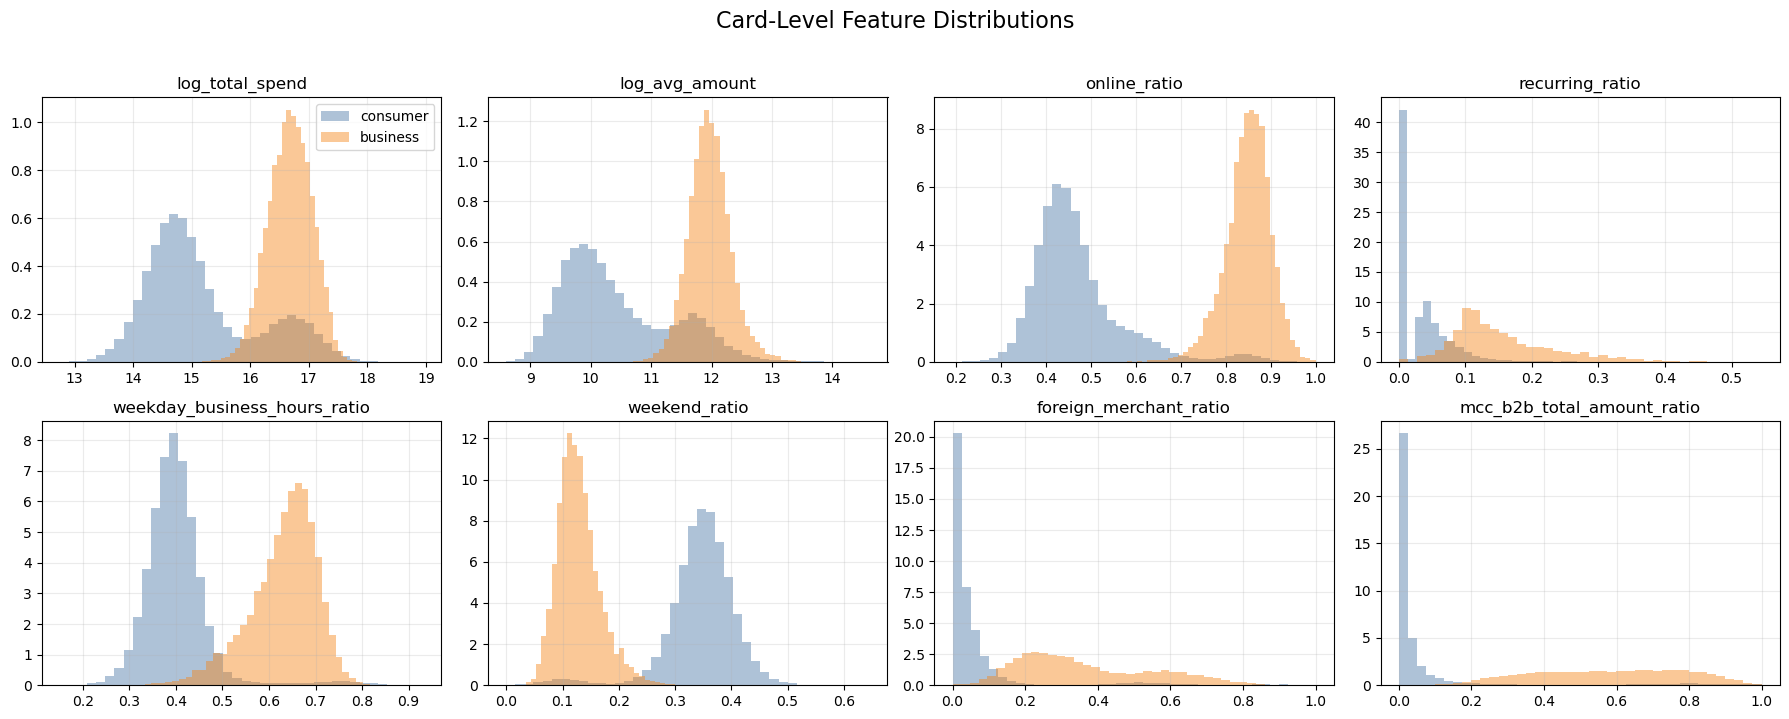

In [8]:
plot_cols = [
    "log_total_spend",
    "log_avg_amount",
    "online_ratio",
    "recurring_ratio",
    "weekday_business_hours_ratio",
    "weekend_ratio",
    "foreign_merchant_ratio",
    "mcc_b2b_total_amount_ratio",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.ravel()
for ax, col in zip(axes, plot_cols):
    for segment, color in [("consumer", "#4c78a8"), ("business", "#f58518")]:
        values = card_features.loc[card_features["segment"] == segment, col]
        ax.hist(values, bins=40, alpha=0.45, density=True, label=segment, color=color)
    ax.set_title(col)
    ax.grid(alpha=0.25)
axes[0].legend()
fig.suptitle("Card-Level Feature Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

EDA выводы коротко:

- transaction count почти одинаковый у business и consumer, значит частота сама по себе слабый сигнал
- business cards тратят больше и имеют выше typical transaction size
- business cards чаще online, recurring, foreign-merchant, B2B-MCC и weekday work-hours
- consumer cards больше уходят в weekend/evening и более размазаны по everyday merchants/MCC

Поэтому признаки ниже не взяты с потолка, они идут из EDA

## 4. Modeling design

Делаю две части.

1. **Supervised baseline**: known business vs consumer. Это нужно чтобы проверить качество features и показать confusion matrix.
2. **PU ranking**: business cards это positives, а consumer cards это unlabeled. Вот это уже ближе к самой задаче, потому что среди consumer могут быть скрытые business-like клиенты.

Supervised baseline не считаю финальным ответом. Он слишком жестко предполагает `consumer = negative`, а это как раз спорное место в кейсе

In [9]:
features = card_features.copy()

if "split" not in features.columns:
    train_idx, temp_idx = train_test_split(
        features.index,
        test_size=0.40,
        stratify=features["label"],
        random_state=RANDOM_STATE,
    )
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.50,
        stratify=features.loc[temp_idx, "label"],
        random_state=RANDOM_STATE,
    )
    features["split"] = ""
    features.loc[train_idx, "split"] = "train"
    features.loc[val_idx, "split"] = "val"
    features.loc[test_idx, "split"] = "test"

features.groupby(["split", "segment"]).size().unstack(fill_value=0)

segment,business,consumer
split,,
test,5000,16000
train,15000,48000
val,5000,16000


In [10]:
ID_COLS = ["card_number", "segment", "label", "split"]
all_feature_cols = [c for c in features.columns if c not in ID_COLS]

# txn_count is kept in the feature table for EDA, but diagnostics showed it adds little signal.
model_feature_cols = [c for c in all_feature_cols if c != "txn_count"]

mcc_group_cols = [c for c in model_feature_cols if c.startswith("mcc_") and c.endswith("_ratio")]
behavior_feature_cols = [c for c in model_feature_cols if c not in mcc_group_cols]

feature_sets = {
    "behavior": behavior_feature_cols,
    "full": model_feature_cols,
    "full_no_online": [c for c in model_feature_cols if c != "online_ratio"],
}

pd.Series({name: len(cols) for name, cols in feature_sets.items()}, name="n_features")

behavior          34
full              50
full_no_online    49
Name: n_features, dtype: int64

## 5. Supervised baseline и сравнение моделей

Здесь сравниваю logistic regression и random forest на validation. Threshold выбирается только на validation, а test остается для финальной проверки. Так мы не подгоняем threshold по test.

In [11]:
def evaluate_scores(y_true, score, threshold=0.5):
    pred = (score >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, score),
        "pr_auc": average_precision_score(y_true, score),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
    }


def best_threshold_by_f1(y_true, score):
    rows = []
    for threshold in np.linspace(0.05, 0.95, 181):
        pred = (score >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "f1": f1_score(y_true, pred, zero_division=0),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
        })
    return pd.DataFrame(rows).sort_values(["f1", "precision", "recall"], ascending=False).iloc[0]


def make_logistic_model():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])


def make_random_forest(max_depth=None, min_samples_leaf=5):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=250,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])

In [12]:
train = features[features["split"] == "train"].copy()
val = features[features["split"] == "val"].copy()
test = features[features["split"] == "test"].copy()

experiments = []
for feature_set_name in ["behavior", "full", "full_no_online"]:
    experiments.append({
        "model_name": "logistic_regression",
        "feature_set": feature_set_name,
        "model": make_logistic_model(),
        "features": feature_sets[feature_set_name],
    })

for feature_set_name in ["behavior", "full"]:
    for max_depth, min_samples_leaf in [(8, 10), (12, 5), (None, 5)]:
        experiments.append({
            "model_name": f"random_forest_depth_{max_depth}_leaf_{min_samples_leaf}",
            "feature_set": feature_set_name,
            "model": make_random_forest(max_depth=max_depth, min_samples_leaf=min_samples_leaf),
            "features": feature_sets[feature_set_name],
        })

comparison_rows = []
fitted_models = {}

for exp in experiments:
    model = exp["model"]
    cols = exp["features"]
    model.fit(train[cols], train["label"])
    val_score = model.predict_proba(val[cols])[:, 1]
    threshold_row = best_threshold_by_f1(val["label"].to_numpy(), val_score)
    metrics = evaluate_scores(val["label"].to_numpy(), val_score, threshold_row["threshold"])

    key = (exp["model_name"], exp["feature_set"])
    fitted_models[key] = model
    comparison_rows.append({
        "model_name": exp["model_name"],
        "feature_set": exp["feature_set"],
        "n_features": len(cols),
        "best_threshold": threshold_row["threshold"],
        **{f"val_{k}": v for k, v in metrics.items()},
    })

model_comparison = pd.DataFrame(comparison_rows).sort_values(["val_f1", "val_pr_auc"], ascending=False)
model_comparison

,model_name,feature_set,n_features,best_threshold,val_roc_auc,val_pr_auc,val_precision,val_recall,val_f1
2,logistic_regression,full_no_online,49,0.9000,1.0000,1.0000,1.0000,1.0000,1.0000
1,logistic_regression,full,50,0.7200,1.0000,1.0000,0.9998,1.0000,0.9999
0,logistic_regression,behavior,34,0.7850,1.0000,1.0000,1.0000,0.9998,0.9999
5,random_forest_depth_None_leaf_5,behavior,34,0.4850,1.0000,1.0000,0.9996,0.9998,0.9997
4,random_forest_depth_12_leaf_5,behavior,34,0.4900,1.0000,1.0000,0.9996,0.9998,0.9997
8,random_forest_depth_None_leaf_5,full,50,0.4150,1.0000,1.0000,0.9992,1.0000,0.9996
7,random_forest_depth_12_leaf_5,full,50,0.5000,1.0000,1.0000,0.9996,0.9996,0.9996
3,random_forest_depth_8_leaf_10,behavior,34,0.5950,1.0000,1.0000,0.9996,0.9992,0.9994
6,random_forest_depth_8_leaf_10,full,50,0.5300,1.0000,1.0000,0.9988,0.9998,0.9993


In [13]:
best = model_comparison.iloc[0]
best_key = (best["model_name"], best["feature_set"])
best_features = feature_sets[best["feature_set"]]
best_threshold = float(best["best_threshold"])
best_model = fitted_models[best_key]

test_score = best_model.predict_proba(test[best_features])[:, 1]
test_metrics = pd.DataFrame([{
    "model_name": best["model_name"],
    "feature_set": best["feature_set"],
    "threshold": best_threshold,
    **evaluate_scores(test["label"].to_numpy(), test_score, best_threshold),
}])

test_pred = (test_score >= best_threshold).astype(int)
cm = confusion_matrix(test["label"], test_pred)
confusion_matrix_df = pd.DataFrame(
    cm,
    index=["actual_consumer", "actual_business"],
    columns=["pred_consumer", "pred_business"],
)

test_metrics

,model_name,feature_set,threshold,roc_auc,pr_auc,precision,recall,f1
0,logistic_regression,full_no_online,0.9000,1.0000,1.0000,1.0000,0.9998,0.9999


In [14]:
confusion_matrix_df

,pred_consumer,pred_business
actual_consumer,16000,0
actual_business,1,4999


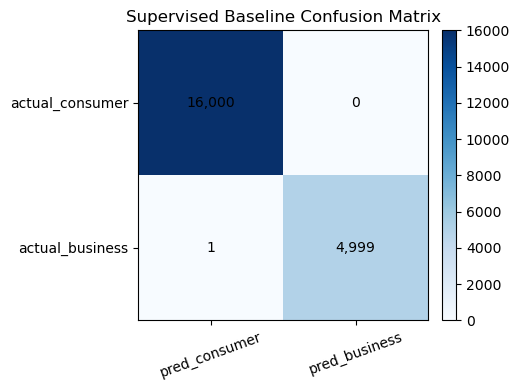

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(confusion_matrix_df.values, cmap="Blues")
ax.set_xticks(range(2), confusion_matrix_df.columns, rotation=20)
ax.set_yticks(range(2), confusion_matrix_df.index)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{confusion_matrix_df.values[i, j]:,}", ha="center", va="center")
ax.set_title("Supervised Baseline Confusion Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Baseline показывает, что наши card-level признаки очень хорошо разделяют известные business и consumer сегменты. Это хороший sanity check.

Но это еще не означает, что мы нашли hidden entrepreneurs. Для этого дальше нужен PU/ranking подход, где consumer не считаются чистыми negative

## 6. Feature sanity check

`online_ratio` выглядит очень сильным признаком, поэтому я отдельно проверяю что будет без него. Если качество почти не падает, значит модель использует не один shortcut, а более широкий behavioral pattern.

In [16]:
ablation_rows = []
for feature_set_name in ["full", "full_no_online", "behavior"]:
    cols = feature_sets[feature_set_name]
    model = make_logistic_model()
    model.fit(train[cols], train["label"])
    val_score = model.predict_proba(val[cols])[:, 1]
    threshold = best_threshold_by_f1(val["label"].to_numpy(), val_score)["threshold"]
    test_score_ablation = model.predict_proba(test[cols])[:, 1]
    ablation_rows.append({
        "feature_set": feature_set_name,
        "n_features": len(cols),
        "val_threshold": threshold,
        **{f"test_{k}": v for k, v in evaluate_scores(test["label"].to_numpy(), test_score_ablation, threshold).items()},
    })

ablation_results = pd.DataFrame(ablation_rows)
ablation_results

,feature_set,n_features,val_threshold,test_roc_auc,test_pr_auc,test_precision,test_recall,test_f1
0,full,50,0.7200,1.0000,1.0000,0.9998,1.0000,0.9999
1,full_no_online,49,0.9000,1.0000,1.0000,1.0000,0.9998,0.9999
2,behavior,34,0.7850,1.0000,1.0000,0.9996,0.9996,0.9996


## 6b. Baseline multi-method check

Теперь делаю похожую проверку как в старом `mdq26_solution.ipynb`, но аккуратнее. Беру supervised probability как один сигнал, потом добавляю два независимых sanity-check сигнала:

- Isolation Forest, обученный только на consumer cards. Он ищет необычных consumer внутри consumer population
- distance to business centroid. Чем ближе card-level профиль к known business cards, тем выше business-like сигнал

Это все еще baseline layer. Он нужен чтобы руками сравнить с PU и показать, что PU не придумал candidates из воздуха.

In [17]:
def add_baseline_multi_method_scores(feature_table, feature_cols):
    feature_table = feature_table.copy()
    if "supervised_business_prob" not in feature_table.columns:
        feature_table["supervised_business_prob"] = best_model.predict_proba(feature_table[feature_cols])[:, 1]

    consumer_part = feature_table[feature_table["segment"] == "consumer"].copy()
    business_part = feature_table[feature_table["segment"] == "business"].copy()

    consumer_x = consumer_part[feature_cols]
    business_x = business_part[feature_cols]

    consumer_preprocess = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    consumer_scaled = consumer_preprocess.fit_transform(consumer_x)

    iso = IsolationForest(
        n_estimators=250,
        contamination=0.01,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    iso.fit(consumer_scaled)
    consumer_part["baseline_anomaly_score"] = -iso.score_samples(consumer_scaled)

    business_preprocess = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    business_scaled = business_preprocess.fit_transform(business_x)
    consumer_scaled_to_business = business_preprocess.transform(consumer_x)
    business_centroid = business_scaled.mean(axis=0)

    consumer_part["baseline_distance_to_business"] = np.linalg.norm(
        consumer_scaled_to_business - business_centroid,
        axis=1,
    )

    consumer_part["baseline_supervised_rank"] = consumer_part["supervised_business_prob"].rank(pct=True)
    consumer_part["baseline_anomaly_rank"] = consumer_part["baseline_anomaly_score"].rank(pct=True)
    consumer_part["baseline_distance_rank"] = (-consumer_part["baseline_distance_to_business"]).rank(pct=True)
    consumer_part["baseline_ensemble_score"] = consumer_part[[
        "baseline_supervised_rank",
        "baseline_anomaly_rank",
        "baseline_distance_rank",
    ]].mean(axis=1)

    return consumer_part[[
        "card_number",
        "baseline_anomaly_score",
        "baseline_distance_to_business",
        "baseline_supervised_rank",
        "baseline_anomaly_rank",
        "baseline_distance_rank",
        "baseline_ensemble_score",
    ]]


baseline_multi_method_scores = add_baseline_multi_method_scores(features, best_features)
baseline_multi_method_scores.sort_values("baseline_ensemble_score", ascending=False).head(20)

,card_number,baseline_anomaly_score,baseline_distance_to_business,baseline_supervised_rank,baseline_anomaly_rank,baseline_distance_rank,baseline_ensemble_score
70258,5368291791007503,0.6615,11.0986,0.9994,0.9942,0.9960,0.9966
77969,5438812366882479,0.6494,11.0269,0.9999,0.9902,0.9964,0.9955
67328,5338474007563215,0.6253,6.8963,0.9999,0.9854,1.0000,0.9951
40973,5176512938679108,0.6443,10.0460,0.9966,0.9888,0.9994,0.9949
71890,5368296289935651,0.6479,11.2693,0.9992,0.9897,0.9951,0.9947
37681,5176476691114937,0.6171,7.3564,0.9999,0.9839,1.0000,0.9946
25601,5100610928479892,0.6200,9.7932,0.9994,0.9845,0.9996,0.9945
27069,5100613360875775,0.6452,10.9910,0.9970,0.9891,0.9966,0.9942
56384,5228590966213212,0.6316,10.7919,0.9988,0.9863,0.9975,0.9942
80961,5438816990479651,0.6228,10.9703,0.9999,0.9850,0.9967,0.9939


Этот baseline ensemble не является финальным решением. Он просто отвечает на вопрос: если взять обычный supervised score и добавить независимые проверки, похожи ли top cards на тот же бизнесовый паттерн. Финальное решение ниже все равно будет PU, потому что consumer это unlabeled, а не clean negative.

## 7. Positive-Unlabeled learning

PU learning здесь нужен потому что у нас есть уверенный positive class, но нет уверенного negative class.

Что делаю:

- PU bagging: много раз беру business cards как positive и случайную часть consumer как temporary negative
- reliable negative model: потом беру самых “обычных” consumer с низким score и учу отдельную модель против business

Финальный `pu_business_score` это ranking score. Это не вероятность что человек точно предприниматель

In [18]:
def fit_pu_bagging(data, feature_cols, n_estimators=40, negative_ratio=1.0, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    train_data = data[data["split"] == "train"]
    positives = train_data[train_data["segment"] == "business"]
    unlabeled = train_data[train_data["segment"] == "consumer"]

    n_negative = min(len(unlabeled), int(len(positives) * negative_ratio))
    all_scores = []

    for _ in range(n_estimators):
        sampled_idx = rng.choice(unlabeled.index.to_numpy(), size=n_negative, replace=False)
        fit_idx = np.concatenate([positives.index.to_numpy(), sampled_idx])
        y_fit = (data.loc[fit_idx, "segment"] == "business").astype(int)

        model = make_logistic_model()
        model.fit(data.loc[fit_idx, feature_cols], y_fit)
        all_scores.append(model.predict_proba(data[feature_cols])[:, 1])

    score_matrix = np.vstack(all_scores)
    return score_matrix.mean(axis=0), score_matrix.std(axis=0)

features = features.copy()
features["pu_bagging_score"], features["pu_bagging_std"] = fit_pu_bagging(
    features,
    feature_sets["full"],
    n_estimators=40,
    negative_ratio=1.0,
)

features.groupby("segment")["pu_bagging_score"].describe()

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
business,"25,000.0000",0.9995,0.0089,0.1849,1.0000,1.0000,1.0000,1.0000
consumer,"80,000.0000",0.0007,0.0158,0.0000,0.0000,0.0000,0.0000,0.9960


In [19]:
train_data = features[features["split"] == "train"]
train_positive = train_data[train_data["segment"] == "business"]
train_unlabeled = train_data[train_data["segment"] == "consumer"]

reliable_negative_pool = train_unlabeled[
    train_unlabeled["pu_bagging_score"] <= train_unlabeled["pu_bagging_score"].quantile(0.30)
]
n_reliable = min(len(reliable_negative_pool), len(train_positive) * 2)
reliable_negatives = reliable_negative_pool.sort_values("pu_bagging_score").head(n_reliable)

rn_train = pd.concat([train_positive, reliable_negatives], axis=0)
rn_y = (rn_train["segment"] == "business").astype(int)

reliable_negative_model = make_logistic_model()
reliable_negative_model.fit(rn_train[feature_sets["full"]], rn_y)
features["reliable_negative_score"] = reliable_negative_model.predict_proba(features[feature_sets["full"]])[:, 1]

pd.Series({
    "train_positives": len(train_positive),
    "train_unlabeled": len(train_unlabeled),
    "reliable_negatives_used": len(reliable_negatives),
    "reliable_negative_pool_max_score": reliable_negatives["pu_bagging_score"].max(),
})

train_positives                    15,000.0000
train_unlabeled                    48,000.0000
reliable_negatives_used            14,400.0000
reliable_negative_pool_max_score        0.0000
dtype: float64

In [20]:
features["pu_bagging_rank"] = features["pu_bagging_score"].rank(pct=True)
features["reliable_negative_rank"] = features["reliable_negative_score"].rank(pct=True)
features["pu_business_score"] = features[["pu_bagging_rank", "reliable_negative_rank"]].mean(axis=1)

supervised_scores = features[["card_number", "segment", "label", "split"]].copy()
supervised_scores["supervised_business_prob"] = best_model.predict_proba(features[best_features])[:, 1]
features = features.merge(supervised_scores[["card_number", "supervised_business_prob"]], on="card_number", how="left")

features.groupby("segment")[["pu_bagging_score", "reliable_negative_score", "pu_business_score", "supervised_business_prob"]].describe()

pu_bagging_score                                                   \
                    count   mean    std    min    25%    50%    75%    max   
segment                                                                      
business      25,000.0000 0.9995 0.0089 0.1849 1.0000 1.0000 1.0000 1.0000   
consumer      80,000.0000 0.0007 0.0158 0.0000 0.0000 0.0000 0.0000 0.9960   

         reliable_negative_score         ... pu_business_score         \
                           count   mean  ...               75%    max   
segment                                  ...                            
business             25,000.0000 0.9999  ...            0.9344 1.0000   
consumer             80,000.0000 0.0164  ...            0.5662 0.8093   

         supervised_business_prob                                            \
                            count   mean    std    min    25%    50%    75%   
segment                                                                       
business              25,000.0000 0.9997 0.0088 0.0552 1.0000 1.0000 1.0000   
consumer              80,000.0000 0.0005 0.0150 0.0000 0.0000 0.0000 0.0000   

                 
            max  
segment          
business 1.0000  
consumer 0.9943  

[2 rows x 32 columns]

## 8. PU validation metrics

Настоящих hidden-business labels внутри consumer нет. Поэтому validation здесь proxy: проверяю, насколько score поднимает held-out known business cards выше consumer background.

Top-K metrics важны именно бизнесово: они показывают насколько хорош верх ranking, где потом будут ручные проверки и outreach.

In [21]:
def ranking_metrics(data, split, score_col, k_fracs=(0.001, 0.005, 0.01, 0.05)):
    eval_df = data[data["split"] == split].copy()
    y = eval_df["label"].to_numpy()
    score = eval_df[score_col].to_numpy()

    row = {
        "split": split,
        "score": score_col,
        "roc_auc_vs_background": roc_auc_score(y, score),
        "pr_auc_vs_background": average_precision_score(y, score),
        "positive_base_rate": y.mean(),
    }

    ranked = eval_df.sort_values(score_col, ascending=False).reset_index(drop=True)
    n_pos = ranked["label"].sum()
    base_rate = ranked["label"].mean()

    for frac in k_fracs:
        k = max(1, int(len(ranked) * frac))
        top = ranked.head(k)
        precision_at_k = top["label"].mean()
        recall_at_k = top["label"].sum() / n_pos
        lift_at_k = precision_at_k / base_rate
        row[f"precision_at_{frac:.1%}"] = precision_at_k
        row[f"recall_at_{frac:.1%}"] = recall_at_k
        row[f"lift_at_{frac:.1%}"] = lift_at_k

    return row

metric_rows = []
for split in ["val", "test"]:
    for score_col in ["pu_bagging_score", "reliable_negative_score", "pu_business_score", "supervised_business_prob"]:
        metric_rows.append(ranking_metrics(features, split, score_col))

pu_validation_metrics = pd.DataFrame(metric_rows)
pu_validation_metrics

,split,score,roc_auc_vs_background,pr_auc_vs_background,positive_base_rate,precision_at_0.1%,recall_at_0.1%,lift_at_0.1%,precision_at_0.5%,recall_at_0.5%,lift_at_0.5%,precision_at_1.0%,recall_at_1.0%,lift_at_1.0%,precision_at_5.0%,recall_at_5.0%,lift_at_5.0%
0,val,pu_bagging_score,1.0000,1.0000,0.2381,1.0000,0.0042,4.2000,1.0000,0.0210,4.2000,1.0000,0.0420,4.2000,1.0000,0.2100,4.2000
1,val,reliable_negative_score,1.0000,1.0000,0.2381,1.0000,0.0042,4.2000,1.0000,0.0210,4.2000,1.0000,0.0420,4.2000,1.0000,0.2100,4.2000
2,val,pu_business_score,1.0000,1.0000,0.2381,1.0000,0.0042,4.2000,1.0000,0.0210,4.2000,1.0000,0.0420,4.2000,1.0000,0.2100,4.2000
3,val,supervised_business_prob,1.0000,1.0000,0.2381,1.0000,0.0042,4.2000,1.0000,0.0210,4.2000,1.0000,0.0420,4.2000,1.0000,0.2100,4.2000
4,test,pu_bagging_score,1.0000,1.0000,0.2381,1.0000,0.0042,4.2000,1.0000,0.0210,4.2000,1.0000,0.0420,4.2000,1.0000,0.2100,4.2000
5,test,reliable_negative_score,1.0000,1.0000,0.2381,1.0000,0.0042,4.2000,1.0000,0.0210,4.2000,1.0000,0.0420,4.2000,1.0000,0.2100,4.2000
6,test,pu_business_score,1.0000,1.0000,0.2381,1.0000,0.0042,4.2000,1.0000,0.0210,4.2000,1.0000,0.0420,4.2000,1.0000,0.2100,4.2000
7,test,supervised_business_prob,1.0000,1.0000,0.2381,1.0000,0.0042,4.2000,1.0000,0.0210,4.2000,1.0000,0.0420,4.2000,1.0000,0.2100,4.2000


**Важная caveat по PU validation.** Эти метрики не доказывают, что каждый top consumer candidate реально владелец бизнеса. Они доказывают только, что score хорошо восстанавливает известный business-like профиль.

Финальный output нужно читать как prioritized lead list, а не как confirmed labels

## 9. Score всех consumer cards и action tiers

Для каждой consumer card считаю `business_like_percent`. Это percentile внутри consumer population.

Например 99.99 означает: карта выглядит более business-like чем 99.99% consumer cards. Это проще и честнее чем называть score вероятностью.

In [22]:
consumer_scores = features[features["segment"] == "consumer"].copy()
consumer_scores = consumer_scores.merge(baseline_multi_method_scores, on="card_number", how="left")
consumer_scores["consumer_score_percentile"] = consumer_scores["pu_business_score"].rank(pct=True)
consumer_scores["business_like_percent"] = consumer_scores["consumer_score_percentile"] * 100


def assign_tier(percentile):
    if percentile >= 0.9995:
        return "tier_1_high_confidence"
    if percentile >= 0.9975:
        return "tier_2_campaign_candidate"
    if percentile >= 0.9900:
        return "tier_3_watchlist"
    return "tier_4_no_action"

consumer_scores["tier"] = consumer_scores["consumer_score_percentile"].apply(assign_tier)

tier_summary = consumer_scores["tier"].value_counts().rename_axis("tier").reset_index(name="cards")
tier_summary["share_of_consumer_cards"] = tier_summary["cards"] / len(consumer_scores)
tier_summary

,tier,cards,share_of_consumer_cards
0,tier_4_no_action,79199,0.9900
1,tier_3_watchlist,600,0.0075
2,tier_2_campaign_candidate,160,0.0020
3,tier_1_high_confidence,41,0.0005


## 9b. Baseline vs PU comparison

Теперь сравниваю baseline ranks с PU ranks. Если пересечение большое, это хороший sanity check. Если не 100%, это тоже нормально: supervised baseline и PU отвечают на разные вопросы.

Baseline спрашивает: насколько card похожа на labeled business vs labeled consumer. PU спрашивает: насколько card похожа на positive class, не доверяя consumer как чистым negative.

In [23]:
def top_set(df, score_col, frac):
    n = max(1, int(len(df) * frac))
    return set(df.nlargest(n, score_col)["card_number"])

comparison_rows = []
for frac in [0.001, 0.005, 0.01, 0.05]:
    pu_top = top_set(consumer_scores, "pu_business_score", frac)
    supervised_top = top_set(consumer_scores, "supervised_business_prob", frac)
    baseline_ensemble_top = top_set(consumer_scores, "baseline_ensemble_score", frac)

    comparison_rows.append({
        "top_share": frac,
        "cards_in_cut": len(pu_top),
        "pu_vs_supervised_overlap": len(pu_top & supervised_top),
        "pu_vs_supervised_overlap_rate": len(pu_top & supervised_top) / len(pu_top),
        "pu_vs_baseline_ensemble_overlap": len(pu_top & baseline_ensemble_top),
        "pu_vs_baseline_ensemble_overlap_rate": len(pu_top & baseline_ensemble_top) / len(pu_top),
    })

baseline_pu_overlap = pd.DataFrame(comparison_rows)
baseline_pu_overlap

,top_share,cards_in_cut,pu_vs_supervised_overlap,pu_vs_supervised_overlap_rate,pu_vs_baseline_ensemble_overlap,pu_vs_baseline_ensemble_overlap_rate
0,0.0010,80,49,0.6125,28,0.3500
1,0.0050,400,242,0.6050,183,0.4575
2,0.0100,800,491,0.6138,384,0.4800
3,0.0500,4000,2654,0.6635,2272,0.5680


Tier thresholds это не “магические вероятности”, а operational cutoffs под бизнес-процесс:

- **top 0.05%**: маленькая очередь на manual review и direct outreach
- **top 0.25%**: аудитория для кампании
- **top 1.00%**: watchlist для мониторинга

В реальном запуске эти пороги надо калибровать под capacity команды, expected conversion, экономику продукта и будущие response labels

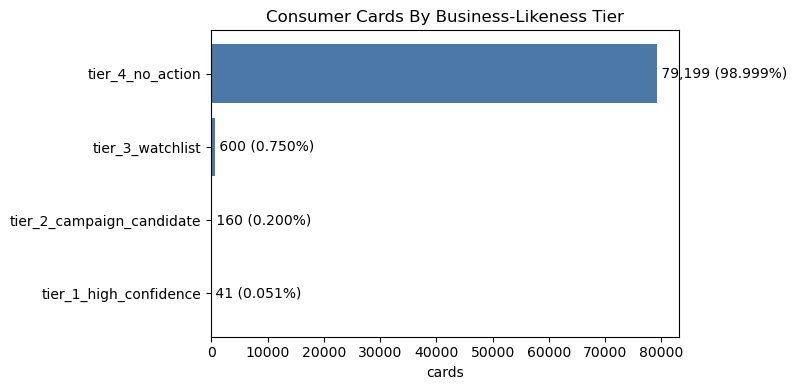

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_tiers = tier_summary.sort_values("share_of_consumer_cards")
ax.barh(plot_tiers["tier"], plot_tiers["cards"], color="#4c78a8")
for i, row in plot_tiers.reset_index(drop=True).iterrows():
    ax.text(row["cards"], i, f" {row['cards']:,} ({row['share_of_consumer_cards']:.3%})", va="center")
ax.set_title("Consumer Cards By Business-Likeness Tier")
ax.set_xlabel("cards")
plt.tight_layout()
plt.show()

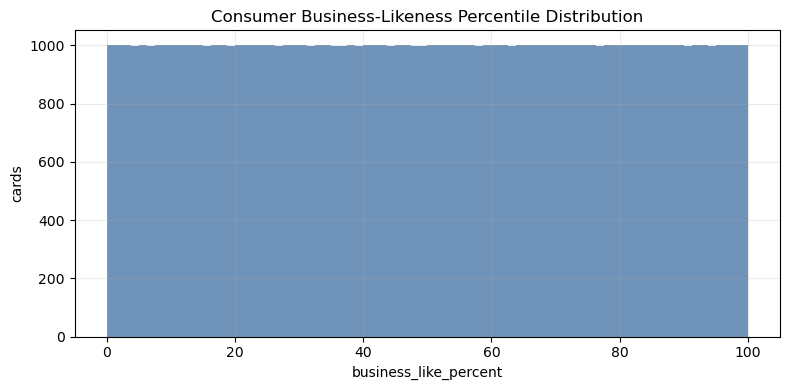

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(consumer_scores["business_like_percent"], bins=80, color="#4c78a8", alpha=0.8)
ax.set_title("Consumer Business-Likeness Percentile Distribution")
ax.set_xlabel("business_like_percent")
ax.set_ylabel("cards")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Portfolio sanity check

Еще одна проверка: не получилось ли так, что top candidates это просто один банк или только Premium cards. Это не полноценная fairness проверка, но она ловит очевидный operational risk перед использованием score.

In [26]:
consumer_card_meta = (
    consumer[["card_number", "bank_name", "card_tier"]]
    .drop_duplicates("card_number")
)
consumer_scores = consumer_scores.merge(consumer_card_meta, on="card_number", how="left")

def tier_distribution_by(column):
    dist = (
        consumer_scores.groupby([column, "tier"])
        .size()
        .unstack(fill_value=0)
    )
    dist["total_cards"] = dist.sum(axis=1)
    for tier in ["tier_1_high_confidence", "tier_2_campaign_candidate", "tier_3_watchlist"]:
        if tier in dist.columns:
            dist[f"{tier}_share"] = dist[tier] / dist["total_cards"]
    return dist.sort_values("total_cards", ascending=False)

bank_tier_distribution = tier_distribution_by("bank_name")
card_tier_distribution = tier_distribution_by("card_tier")

bank_tier_distribution.head(10)

tier,tier_1_high_confidence,tier_2_campaign_candidate,tier_3_watchlist,tier_4_no_action,total_cards,tier_1_high_confidence_share,tier_2_campaign_candidate_share,tier_3_watchlist_share
bank_name,,,,,,,,
Kaspi,12,59,200,25323,25594,0.0005,0.0023,0.0078
Halyk,8,35,141,18874,19058,0.0004,0.0018,0.0074
Forte Bank,5,18,49,7225,7297,0.0007,0.0025,0.0067
Bereke Bank,3,12,30,5536,5581,0.0005,0.0022,0.0054
Home Credit Bank,4,9,40,4758,4811,0.0008,0.0019,0.0083
BCC Bank,3,8,43,4745,4799,0.0006,0.0017,0.0090
Freedom Bank,0,5,29,3970,4004,0.0000,0.0012,0.0072
Eurasian Bank,2,4,18,3287,3311,0.0006,0.0012,0.0054
Bank RBK,2,4,19,2375,2400,0.0008,0.0017,0.0079


In [27]:
card_tier_distribution

tier,tier_1_high_confidence,tier_2_campaign_candidate,tier_3_watchlist,tier_4_no_action,total_cards,tier_1_high_confidence_share,tier_2_campaign_candidate_share,tier_3_watchlist_share
card_tier,,,,,,,,
Standard,31,113,388,63569,64101,0.0005,0.0018,0.0061
Affluent,8,40,179,13315,13542,0.0006,0.0030,0.0132
Premium,2,7,33,2315,2357,0.0008,0.0030,0.0140


Эта проверка не участвует в обучении. Это просто sanity check для внедрения. Если бы tier 1 был почти весь из одного банка или одного card tier, score надо было бы дополнительно разбирать перед кампанией

## 11. Explain top candidates

Теперь смотрю не только score, но и причины. Reasons строятся через сравнение поведения карты с business medians. Это помогает не продавать модель как black box.

Top candidates считаются по всем consumer cards, включая train/validation/test split. Split оставлен в таблице специально для прозрачности.

Метрики качества считаются отдельно на validation/test, а этот список это уже inference output по всему consumer portfolio.

In [28]:
reason_cols = [
    "log_total_spend",
    "online_ratio",
    "recurring_ratio",
    "recurring_capable_ratio",
    "foreign_merchant_ratio",
    "weekday_business_hours_ratio",
    "weekend_ratio",
    "evening_ratio",
    "mcc_b2b_total_ratio",
    "mcc_b2b_total_amount_ratio",
]

business_median = features[features["segment"] == "business"][reason_cols].median()


def explain_candidate(row):
    reasons = []
    if row["mcc_b2b_total_amount_ratio"] >= business_median["mcc_b2b_total_amount_ratio"]:
        reasons.append("B2B spend share like business")
    if row["foreign_merchant_ratio"] >= business_median["foreign_merchant_ratio"]:
        reasons.append("high foreign merchant exposure")
    if row["recurring_ratio"] >= business_median["recurring_ratio"]:
        reasons.append("high recurring payments")
    if row["recurring_capable_ratio"] >= business_median["recurring_capable_ratio"]:
        reasons.append("many recurring-capable merchants")
    if row["weekday_business_hours_ratio"] >= business_median["weekday_business_hours_ratio"]:
        reasons.append("work-hours heavy")
    if row["weekend_ratio"] <= business_median["weekend_ratio"]:
        reasons.append("low weekend usage")
    if row["evening_ratio"] <= business_median["evening_ratio"]:
        reasons.append("low evening usage")
    if row["log_total_spend"] >= business_median["log_total_spend"]:
        reasons.append("business-level total spend")
    if row["online_ratio"] >= business_median["online_ratio"]:
        reasons.append("online-heavy")
    return "; ".join(reasons[:5]) if reasons else "borderline composite pattern; inspect transaction profile"

consumer_scores["pu_reasons"] = consumer_scores.apply(explain_candidate, axis=1)

score_cols = [
    "card_number",
    "split",
    "pu_business_score",
    "business_like_percent",
    "tier",
    "pu_reasons",
    "pu_bagging_score",
    "pu_bagging_std",
    "reliable_negative_score",
    "supervised_business_prob",
    "baseline_ensemble_score",
    "baseline_anomaly_score",
    "baseline_distance_to_business",
]

top_candidates = consumer_scores.sort_values("pu_business_score", ascending=False).head(100)
top_candidates[score_cols + reason_cols].head(20)

,card_number,split,pu_business_score,business_like_percent,tier,pu_reasons,pu_bagging_score,pu_bagging_std,reliable_negative_score,supervised_business_prob,...,log_total_spend,online_ratio,recurring_ratio,recurring_capable_ratio,foreign_merchant_ratio,weekday_business_hours_ratio,weekend_ratio,evening_ratio,mcc_b2b_total_ratio,mcc_b2b_total_amount_ratio
25695,5201491354169846,train,0.8093,100.0000,tier_1_high_confidence,high foreign merchant exposure; high recurring...,0.9960,0.0035,0.9999,0.9943,...,16.4282,0.8846,0.2308,0.4231,0.4423,0.6538,0.0769,0.0769,0.2692,0.3806
42328,5338474007563215,train,0.7647,99.9988,tier_1_high_confidence,high foreign merchant exposure; high recurring...,0.8964,0.0930,0.9992,0.7384,...,16.5119,0.8495,0.1935,0.3548,0.5591,0.6774,0.0968,0.0753,0.4839,0.4629
19522,5176516958585590,test,0.7647,99.9975,tier_1_high_confidence,B2B spend share like business; high foreign me...,0.8842,0.0276,0.9992,0.8326,...,16.8381,0.8986,0.2609,0.8551,0.7536,0.5797,0.1159,0.0580,0.7391,0.8678
12681,5176476691114937,train,0.7647,99.9963,tier_1_high_confidence,B2B spend share like business; high foreign me...,0.9422,0.0583,0.9991,0.7773,...,16.0171,0.8701,0.2338,0.3636,0.3636,0.5714,0.0909,0.1169,0.3506,0.6644
55961,5438816990479651,val,0.7643,99.9950,tier_1_high_confidence,work-hours heavy; low weekend usage; low eveni...,0.8736,0.1126,0.9991,0.7849,...,17.2133,0.7765,0.0000,0.0000,0.0000,0.8588,0.0235,0.0588,0.3294,0.3997
47476,5368297894191789,test,0.7643,99.9938,tier_1_high_confidence,B2B spend share like business; high foreign me...,0.7069,0.0752,0.9991,0.7254,...,17.4043,0.7857,0.3214,0.8393,0.7857,0.5357,0.1250,0.0714,0.8036,0.9247
52969,5438812366882479,train,0.7642,99.9925,tier_1_high_confidence,B2B spend share like business; high foreign me...,0.8787,0.1575,0.9990,0.7798,...,16.3684,0.7778,0.1481,0.7284,0.7407,0.7284,0.0617,0.1111,0.8148,0.8081
70862,5500442485584260,train,0.7641,99.9912,tier_1_high_confidence,B2B spend share like business; high foreign me...,0.9259,0.0618,0.9990,0.9906,...,17.6052,0.8654,0.3462,0.8077,0.8077,0.5000,0.1731,0.0962,0.7115,0.9811
1262,5100612020402608,val,0.7637,99.9900,tier_1_high_confidence,high recurring payments; many recurring-capabl...,0.9315,0.0691,0.9988,0.8959,...,16.3873,0.8276,0.1552,0.3017,0.3017,0.6810,0.1121,0.1121,0.2241,0.5391
28260,5211551692085315,train,0.7636,99.9888,tier_1_high_confidence,B2B spend share like business; high foreign me...,0.4250,0.1091,0.9989,0.1265,...,16.8499,0.9048,0.4286,0.8571,0.8571,0.5000,0.1190,0.0952,0.7143,0.9135


## 12. Manual transaction-level review

Здесь открываю транзакции top candidates и смотрю реальные merchants и MCC names. Это важный шаг, потому что бизнесу нужен не просто score, а понятное объяснение почему эта карта попала наверх.

In [29]:
top_card_numbers = top_candidates["card_number"].head(50).tolist()
top_txn = consumer[consumer["card_number"].isin(top_card_numbers)].copy()
top_txn["mcc"] = top_txn["mcc"].astype(str)

merchants_no_mcc = merchants.drop(columns=["mcc"]).copy()
top_txn = top_txn.merge(merchants_no_mcc, on="merchant_id", how="left")

mcc_ref = mcc[["mcc", "mcc_name"]].copy()
mcc_ref["mcc"] = mcc_ref["mcc"].astype(str)
top_txn = top_txn.merge(mcc_ref, on="mcc", how="left")

placeholder_mask = (top_txn["merchant_id"] == "MER_000000") & (top_txn["mcc"] == "7012")
top_txn.loc[placeholder_mask, "merchant_name"] = "MER_000000 / MCC 7012 placeholder"

top_txn["ts"] = pd.to_datetime(top_txn["transaction_timestamp"])
top_txn["is_online"] = top_txn["channel"].str.lower().eq("online")
top_txn["is_weekend"] = top_txn["ts"].dt.dayofweek >= 5
top_txn["weekday_business_hours"] = (~top_txn["is_weekend"]) & top_txn["ts"].dt.hour.between(9, 18)
top_txn["foreign_merchant"] = top_txn["merchant_country"].ne(LOCAL_COUNTRY)

b2b_codes = {"7311", "7372", "7399", "7392", "5943", "5111", "4814", "4816", "4214", "4215", "4225", "8111", "8931", "8999"}
top_txn["is_b2b_mcc"] = top_txn["mcc"].isin(b2b_codes)


def top_values(series, n=5):
    return "; ".join([f"{idx}: {val}" for idx, val in series.value_counts().head(n).items()])

txn_profile = top_txn.groupby("card_number").agg(
    txn_count=("transaction_amount_kzt", "size"),
    total_spend=("transaction_amount_kzt", "sum"),
    avg_amount=("transaction_amount_kzt", "mean"),
    online_ratio=("is_online", "mean"),
    recurring_ratio=("is_recurring", "mean"),
    foreign_merchant_ratio=("foreign_merchant", "mean"),
    weekday_business_hours_ratio=("weekday_business_hours", "mean"),
    b2b_mcc_ratio=("is_b2b_mcc", "mean"),
    top_merchants=("merchant_name", top_values),
    top_mcc_names=("mcc_name", top_values),
).reset_index()

top_candidate_profiles = top_candidates[score_cols + reason_cols].merge(txn_profile, on="card_number", how="left")
top_candidate_profiles.head(20)

,card_number,split,pu_business_score,business_like_percent,tier,pu_reasons,pu_bagging_score,pu_bagging_std,reliable_negative_score,supervised_business_prob,...,txn_count,total_spend,avg_amount,online_ratio_y,recurring_ratio_y,foreign_merchant_ratio_y,weekday_business_hours_ratio_y,b2b_mcc_ratio,top_merchants,top_mcc_names
0,5201491354169846,train,0.8093,100.0000,tier_1_high_confidence,high foreign merchant exposure; high recurring...,0.9960,0.0035,0.9999,0.9943,...,52.0000,"13,635,876.0000","262,228.3846",0.8846,0.2308,0.4423,0.6538,0.2692,CommuterTransport_1921: 17; HubSpot: 14; Canva...,Transportation: Suburban and Local Commuter Pa...
1,5338474007563215,train,0.7647,99.9988,tier_1_high_confidence,high foreign merchant exposure; high recurring...,0.8964,0.0930,0.9992,0.7384,...,93.0000,"14,825,660.0000","159,415.6989",0.8495,0.1935,0.5591,0.6774,0.4839,DurableGoods_9947: 29; FedEx: 19; Salesforce: ...,Durable Goods: not elsewhere classified: 29; C...
2,5176516958585590,test,0.7647,99.9975,tier_1_high_confidence,B2B spend share like business; high foreign me...,0.8842,0.0276,0.9992,0.8326,...,69.0000,"20,545,012.0000","297,753.7971",0.8986,0.2609,0.7536,0.5797,0.7391,Instagram Promote: 37; Notion: 8; Children's/I...,Advertising Services: 37; Direct Marketing: Co...
3,5176476691114937,train,0.7647,99.9963,tier_1_high_confidence,B2B spend share like business; high foreign me...,0.9422,0.0583,0.9991,0.7773,...,77.0000,"9,039,253.0000","117,392.8961",0.8701,0.2338,0.3636,0.5714,0.3506,PackageStores-Bee_3021: 27; Atlassian: 11; GoD...,"Package Stores, Beer, Wine, and Liquor: 27; Co..."
4,5438816990479651,val,0.7643,99.9950,tier_1_high_confidence,work-hours heavy; low weekend usage; low eveni...,0.8736,0.1126,0.9991,0.7849,...,85.0000,"29,896,519.0000","351,723.7529",0.7765,0.0000,0.0000,0.8588,0.3294,FamilyClothingSt_6936: 33; Pony Express KZ: 19...,Family Clothing Stores: 33; Courier Services: ...
5,5368297894191789,test,0.7643,99.9938,tier_1_high_confidence,B2B spend share like business; high foreign me...,0.7069,0.0752,0.9991,0.7254,...,56.0000,"36,188,922.0000","646,230.7500",0.7857,0.3214,0.7857,0.5357,0.8036,TikTok Ads: 25; Microsoft Azure: 9; ComputerNe...,Advertising Services: 25; Computer Programming...
6,5438812366882479,train,0.7642,99.9925,tier_1_high_confidence,B2B spend share like business; high foreign me...,0.8787,0.1575,0.9990,0.7798,...,81.0000,"12,843,861.0000","158,566.1852",0.7778,0.1481,0.7407,0.7284,0.8148,GoDaddy: 36; Amazon Web Services: 23; DurableG...,Computer Network/Information Services: 36; Com...
7,5500442485584260,train,0.7641,99.9912,tier_1_high_confidence,B2B spend share like business; high foreign me...,0.9259,0.0618,0.9990,0.9906,...,52.0000,"44,244,475.0000","850,855.2885",0.8654,0.3462,0.8077,0.5000,0.7115,Yandex Direct: 30; Taxicabs/Limousine_8351: 7;...,Advertising Services: 30; Limousines and Taxic...
8,5100612020402608,val,0.7637,99.9900,tier_1_high_confidence,high recurring payments; many recurring-capabl...,0.9315,0.0691,0.9988,0.8959,...,116.0000,"13,089,362.0000","112,839.3276",0.8276,0.1552,0.3017,0.6810,0.2241,PackageStores-Bee_3840: 44; Hotel/Lodging(Cod_...,"Package Stores, Beer, Wine, and Liquor: 44; Lo..."
9,5211551692085315,train,0.7636,99.9888,tier_1_high_confidence,B2B spend share like business; high foreign me...,0.4250,0.1091,0.9989,0.1265,...,42.0000,"20,788,658.0000","494,968.0476",0.9048,0.4286,0.8571,0.5000,0.7143,Instagram Promote: 18; Salesforce: 6; Hetzner:...,Advertising Services: 18; Computer Programming...


## 13. Business review table

Финальный результат должен превращаться в действие. Поэтому собираю таблицу для ручного просмотра: карта, business-like percent, reasons, top merchants, top MCC и recommended action.

In [30]:
def recommended_action(tier):
    if tier == "tier_1_high_confidence":
        return "manual review + direct SME/business-card outreach"
    if tier == "tier_2_campaign_candidate":
        return "personalized digital campaign for business products"
    if tier == "tier_3_watchlist":
        return "monitor behavior and rescore next period"
    return "no action"

business_review_cols = [
    "card_number",
    "business_like_percent",
    "tier",
    "pu_reasons",
    "top_merchants",
    "top_mcc_names",
    "total_spend",
    "online_ratio_y",
    "recurring_ratio_y",
    "foreign_merchant_ratio_y",
    "b2b_mcc_ratio",
]

top10_business_review = top_candidate_profiles[business_review_cols].head(10).copy()
top10_business_review["recommended_action"] = top10_business_review["tier"].apply(recommended_action)
top10_business_review

,card_number,business_like_percent,tier,pu_reasons,top_merchants,top_mcc_names,total_spend,online_ratio_y,recurring_ratio_y,foreign_merchant_ratio_y,b2b_mcc_ratio,recommended_action
0,5201491354169846,100.0000,tier_1_high_confidence,high foreign merchant exposure; high recurring...,CommuterTransport_1921: 17; HubSpot: 14; Canva...,Transportation: Suburban and Local Commuter Pa...,"13,635,876.0000",0.8846,0.2308,0.4423,0.2692,manual review + direct SME/business-card outreach
1,5338474007563215,99.9988,tier_1_high_confidence,high foreign merchant exposure; high recurring...,DurableGoods_9947: 29; FedEx: 19; Salesforce: ...,Durable Goods: not elsewhere classified: 29; C...,"14,825,660.0000",0.8495,0.1935,0.5591,0.4839,manual review + direct SME/business-card outreach
2,5176516958585590,99.9975,tier_1_high_confidence,B2B spend share like business; high foreign me...,Instagram Promote: 37; Notion: 8; Children's/I...,Advertising Services: 37; Direct Marketing: Co...,"20,545,012.0000",0.8986,0.2609,0.7536,0.7391,manual review + direct SME/business-card outreach
3,5176476691114937,99.9963,tier_1_high_confidence,B2B spend share like business; high foreign me...,PackageStores-Bee_3021: 27; Atlassian: 11; GoD...,"Package Stores, Beer, Wine, and Liquor: 27; Co...","9,039,253.0000",0.8701,0.2338,0.3636,0.3506,manual review + direct SME/business-card outreach
4,5438816990479651,99.9950,tier_1_high_confidence,work-hours heavy; low weekend usage; low eveni...,FamilyClothingSt_6936: 33; Pony Express KZ: 19...,Family Clothing Stores: 33; Courier Services: ...,"29,896,519.0000",0.7765,0.0000,0.0000,0.3294,manual review + direct SME/business-card outreach
5,5368297894191789,99.9938,tier_1_high_confidence,B2B spend share like business; high foreign me...,TikTok Ads: 25; Microsoft Azure: 9; ComputerNe...,Advertising Services: 25; Computer Programming...,"36,188,922.0000",0.7857,0.3214,0.7857,0.8036,manual review + direct SME/business-card outreach
6,5438812366882479,99.9925,tier_1_high_confidence,B2B spend share like business; high foreign me...,GoDaddy: 36; Amazon Web Services: 23; DurableG...,Computer Network/Information Services: 36; Com...,"12,843,861.0000",0.7778,0.1481,0.7407,0.8148,manual review + direct SME/business-card outreach
7,5500442485584260,99.9912,tier_1_high_confidence,B2B spend share like business; high foreign me...,Yandex Direct: 30; Taxicabs/Limousine_8351: 7;...,Advertising Services: 30; Limousines and Taxic...,"44,244,475.0000",0.8654,0.3462,0.8077,0.7115,manual review + direct SME/business-card outreach
8,5100612020402608,99.9900,tier_1_high_confidence,high recurring payments; many recurring-capabl...,PackageStores-Bee_3840: 44; Hotel/Lodging(Cod_...,"Package Stores, Beer, Wine, and Liquor: 44; Lo...","13,089,362.0000",0.8276,0.1552,0.3017,0.2241,manual review + direct SME/business-card outreach
9,5211551692085315,99.9888,tier_1_high_confidence,B2B spend share like business; high foreign me...,Instagram Promote: 18; Salesforce: 6; Hetzner:...,Advertising Services: 18; Computer Programming...,"20,788,658.0000",0.9048,0.4286,0.8571,0.7143,manual review + direct SME/business-card outreach


## Risk and error analysis

Даже при хороших метриках модель может ошибаться. Поэтому отдельно фиксирую, где возможны false positives и false negatives. Это честнее чем просто показать AUC и сказать что все отлично

In [31]:
risk_analysis = pd.DataFrame([
    {
        "risk_type": "false_positive",
        "example": "affluent consumer with many subscriptions or foreign digital services",
        "why_it_matters": "may look business-like without actually running a business",
        "mitigation": "manual review of top merchants/MCCs; validate with CRM or product uptake",
    },
    {
        "risk_type": "false_positive",
        "example": "traveler or expat with high foreign merchant exposure",
        "why_it_matters": "foreign merchant ratio may be high for non-business reasons",
        "mitigation": "combine foreign exposure with B2B MCC, recurring, and work-hours signals",
    },
    {
        "risk_type": "false_negative",
        "example": "cash-heavy small merchant or offline seller",
        "why_it_matters": "may not buy SaaS/ads/cloud or use obvious B2B MCCs",
        "mitigation": "add incoming-flow and acquiring/POS data if available",
    },
    {
        "risk_type": "false_negative",
        "example": "low-volume self-employed client",
        "why_it_matters": "behavior may be too close to normal consumer spend",
        "mitigation": "use longer history and response labels from campaigns",
    },
])
risk_analysis

,risk_type,example,why_it_matters,mitigation
0,false_positive,affluent consumer with many subscriptions or f...,may look business-like without actually runnin...,manual review of top merchants/MCCs; validate ...
1,false_positive,traveler or expat with high foreign merchant e...,foreign merchant ratio may be high for non-bus...,"combine foreign exposure with B2B MCC, recurri..."
2,false_negative,cash-heavy small merchant or offline seller,may not buy SaaS/ads/cloud or use obvious B2B ...,add incoming-flow and acquiring/POS data if av...
3,false_negative,low-volume self-employed client,behavior may be too close to normal consumer s...,use longer history and response labels from ca...


## 14. Save final outputs

Сохраняю таблицы, которые нужны для презентации, проверки и ручного просмотра candidates.

In [32]:
final_dir = PROCESSED_DIR

model_comparison.to_csv(final_dir / "final_model_comparison.csv", index=False)
test_metrics.to_csv(final_dir / "final_baseline_test_metrics.csv", index=False)
confusion_matrix_df.to_csv(final_dir / "final_baseline_confusion_matrix.csv")
ablation_results.to_csv(final_dir / "final_ablation_results.csv", index=False)
pu_validation_metrics.to_csv(final_dir / "final_pu_validation_metrics.csv", index=False)
baseline_multi_method_scores.to_csv(final_dir / "final_baseline_multi_method_scores.csv", index=False)
baseline_pu_overlap.to_csv(final_dir / "final_baseline_pu_overlap.csv", index=False)
tier_summary.to_csv(final_dir / "final_pu_tier_summary.csv", index=False)
bank_tier_distribution.to_csv(final_dir / "final_tier_by_bank.csv")
card_tier_distribution.to_csv(final_dir / "final_tier_by_card_tier.csv")

consumer_scores[score_cols + reason_cols].to_parquet(final_dir / "final_consumer_scores.parquet", index=False, engine="fastparquet")
consumer_scores[score_cols + reason_cols].to_csv(final_dir / "final_consumer_scores.csv", index=False)
top_candidates[score_cols + reason_cols].to_csv(final_dir / "final_top_candidates.csv", index=False)
top_candidate_profiles.to_csv(final_dir / "final_top_candidate_transaction_profiles.csv", index=False)
top10_business_review.to_csv(final_dir / "final_top10_business_review.csv", index=False)
risk_analysis.to_csv(final_dir / "final_risk_analysis.csv", index=False)

pd.Series({
    "final_model_comparison": str(final_dir / "final_model_comparison.csv"),
    "final_consumer_scores": str(final_dir / "final_consumer_scores.parquet"),
    "final_top_candidates": str(final_dir / "final_top_candidates.csv"),
    "final_baseline_pu_overlap": str(final_dir / "final_baseline_pu_overlap.csv"),
    "final_top_candidate_transaction_profiles": str(final_dir / "final_top_candidate_transaction_profiles.csv"),
    "final_top10_business_review": str(final_dir / "final_top10_business_review.csv"),
})

final_model_comparison                      /Users/sapuantalaspay/vs_projects/data/data/pr...
final_consumer_scores                       /Users/sapuantalaspay/vs_projects/data/data/pr...
final_top_candidates                        /Users/sapuantalaspay/vs_projects/data/data/pr...
final_baseline_pu_overlap                   /Users/sapuantalaspay/vs_projects/data/data/pr...
final_top_candidate_transaction_profiles    /Users/sapuantalaspay/vs_projects/data/data/pr...
final_top10_business_review                 /Users/sapuantalaspay/vs_projects/data/data/pr...
dtype: object

## Final interpretation and recommendation

Итог: модель строит prioritized list consumer cards с business-like transactional behavior.

Что получилось:

- supervised baseline подтверждает, что card-level features хорошо разделяют known business и consumer
- лучший baseline хорошо работает даже без `online_ratio`, значит это не один shortcut
- для финального поиска используется PU learning, потому что consumer cards это unlabeled, а не confirmed negative
- `business_like_percent` это percentile среди consumer cards, не точная probability
- tiers превращают ranking в понятный workflow: direct review, campaign, watchlist, no action
- top candidates можно объяснить через merchants, MCC и behavioral reasons

Business recommendation:

- tier 1 отдать на manual review и direct SME/business-card outreach
- tier 2 использовать для personalized campaign по business cards, acquiring, working-capital credit и merchant services
- tier 3 оставить в watchlist и перескорить на следующем периоде
- ответы на кампании и product uptake потом использовать как labels для калибровки и retraining

Limitations:

- в данных нет явного incoming/outgoing flow, поэтому мы ищем business-like card behavior, а не подтвержденный merchant revenue
- внутри consumer нет ground truth по hidden entrepreneurs
- PU scores ранжируют похожесть на known business behavior, это не точные вероятности
- top candidates нужно валидировать через CRM/product data банка перед реальным использованием
- почти идеальные supervised metrics ожидаемы на синтетических данных и не должны продаваться как гарантия real-world качества